# Phase 3B — Hybrid CNN-ViT for ASD Detection

**Project:** ASD Detection from Structural MRI (ABIDE-I)  
**Author:** Tarun Sadarla · University of North Texas (MS AI, Biomedical Concentration)  
**Environment:** Google Colab Pro · T4 GPU  
**Data:** Kaggle datasets via API

---

## Why Hybrid CNN-ViT?

Every previous project in this portfolio used CNNs (custom 5-layer, VGG16, 2D U-Net, Temporal U-Net). This notebook introduces self-attention as the core classification mechanism — the first transformer-based architecture in the portfolio.

**Why not a pure ViT?** Three reasons specific to this dataset:
1. ~67K training slices is insufficient for a ViT to learn translation equivariance from scratch (CNNs get it for free)
2. 30–40% of each sMRI slice is black skull background — raw patch tokens waste sequence length on uninformative regions
3. Pretrained ImageNet ViTs have a domain mismatch; the B.Tech attempt used lr=1e-3 which destroys pretrained weights in the first few steps

**The hybrid solution:**
- CNN backbone (conv1–conv4, Phase 2 weights, frozen then lightly fine-tuned) → extracts 14×14 spatial feature tokens
- Brain mask filters background tokens before the transformer sees them
- Transformer encoder (4 layers, 8 heads) → learns long-range spatial dependencies across brain-region tokens
- Attention maps from the CLS token provide spatial interpretability directly comparable to GradCAM

## Architecture summary

```
Input (B,3,224,224)
  → Brain mask generation (Otsu threshold + morphological closing)
  → CNN backbone conv1–4  →  (B,128,14,14)  [196 spatial tokens]
  → Background token zeroing (mask applied at token resolution)
  → Linear projection 128→256  →  (B,196,256)
  → + 2D sinusoidal positional embeddings
  → CLS token prepend  →  (B,197,256)
  → Transformer encoder (4 × [Pre-LN MultiheadAttn + FFN])
  → CLS → LayerNorm → Linear(256,2)  →  (B,2) logits
```

Total parameters ≈ 1.7M (comparable to original CNN).

## 0. Colab Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
import os, shutil

# Prompt for manual upload
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Create the Kaggle directory
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Move the uploaded file to the required hidden directory
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))

# Set the necessary permissions to keep the API key secure
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print('kaggle.json configured successfully via manual upload.')

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
kaggle.json configured successfully via manual upload.


In [3]:
!pip install kaggle grad-cam -q
os.makedirs('/content/data', exist_ok=True)
print('Downloading CSV + weights...')
!kaggle datasets download -d tarunsadarla/autism-csv -p /content/data/autism-csv --unzip -q
!kaggle datasets download -d tarunsadarla/xai-asd-gradcam-lime-outputs -p /content/data/weights --unzip -q
IMG_ROOT='/content/data/autism'
if not os.path.exists(IMG_ROOT) or len(os.listdir(IMG_ROOT))<100:
    print('Downloading image dataset (large — several minutes)...')
    !kaggle datasets download -d tarunsadarla/autism -p /content/data/autism --unzip -q
else:
    print('Image dataset already present.')
import torch
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
if torch.cuda.is_available(): print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/autism-csv
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/xai-asd-gradcam-lime-outputs
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/autism
License(s): unknown
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Configuration

In [4]:
IMG_ROOT         = '/content/data/autism'
TRAIN_CSV        = '/content/data/autism-csv/clean_train.csv'
VAL_CSV          = '/content/data/autism-csv/clean_val.csv'
TEST_CSV         = '/content/data/autism-csv/clean_test.csv'
PHENOTYPIC_CSV   = '/content/data/autism-csv/5320_ABIDE_Phenotypics_20230908.csv'
CNN_WEIGHTS      = '/content/data/weights/xai_cnn_best_weights.pth'  # Phase 2
OUT_DIR          = '/content/outputs/phase3b'
os.makedirs(OUT_DIR, exist_ok=True)

# Transformer architecture
EMBED_DIM = 256;  N_HEADS = 8;  N_LAYERS = 4;  FF_DIM = 512;  DROPOUT = 0.1
CNN_OUT_CH = 128; FEAT_SIZE = 14  # 224 / 2^4 = 14
N_TOKENS   = FEAT_SIZE**2         # 196

# Brain masking
MASK_THRESHOLD  = 0.05
MIN_BRAIN_TOKENS= 20

# Training — differential LR
LR_BACKBONE    = 2e-5   # 10× lower than transformer
LR_TRANSFORMER = 2e-4
WEIGHT_DECAY   = 1e-4
WARMUP_EPOCHS  = 3
TOTAL_EPOCHS   = 30
FREEZE_EPOCHS  = 5      # backbone frozen for first N epochs
BATCH_SIZE     = 32     # Colab T4 safe
PATIENCE       = 6

MEAN = [0.1425056904554367]*3
STD  = [0.19151894748210907]*3
SEED = 42
print('Configuration loaded.')

Configuration loaded.


## 2. Imports

In [5]:
import math, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_mod
from PIL import Image
from tqdm import tqdm
import cv2
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    f1_score, average_precision_score, brier_score_loss
)

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | PyTorch: {torch.__version__}')

Device: cuda | PyTorch: 2.10.0+cu128


## 3. Brain Mask Generation

### The background token problem

sMRI axial slices have large black regions (skull exterior, corners). After the CNN reduces to 14×14, these become background tokens. If fed to the transformer unmasked:
- Attention heads waste capacity on uninformative zero-signal tokens
- Positional embeddings create spurious biases (corner = always background)
- CLS token aggregates brain + non-brain signal indiscriminately

**Fix:** Otsu-style threshold on the input image → binary brain mask → downsample to 14×14 token resolution → zero out feature vectors at background positions before the projection layer. Brain tokens retain full CNN-encoded signal; background tokens become zero vectors that self-attention naturally ignores (near-zero softmax weights).

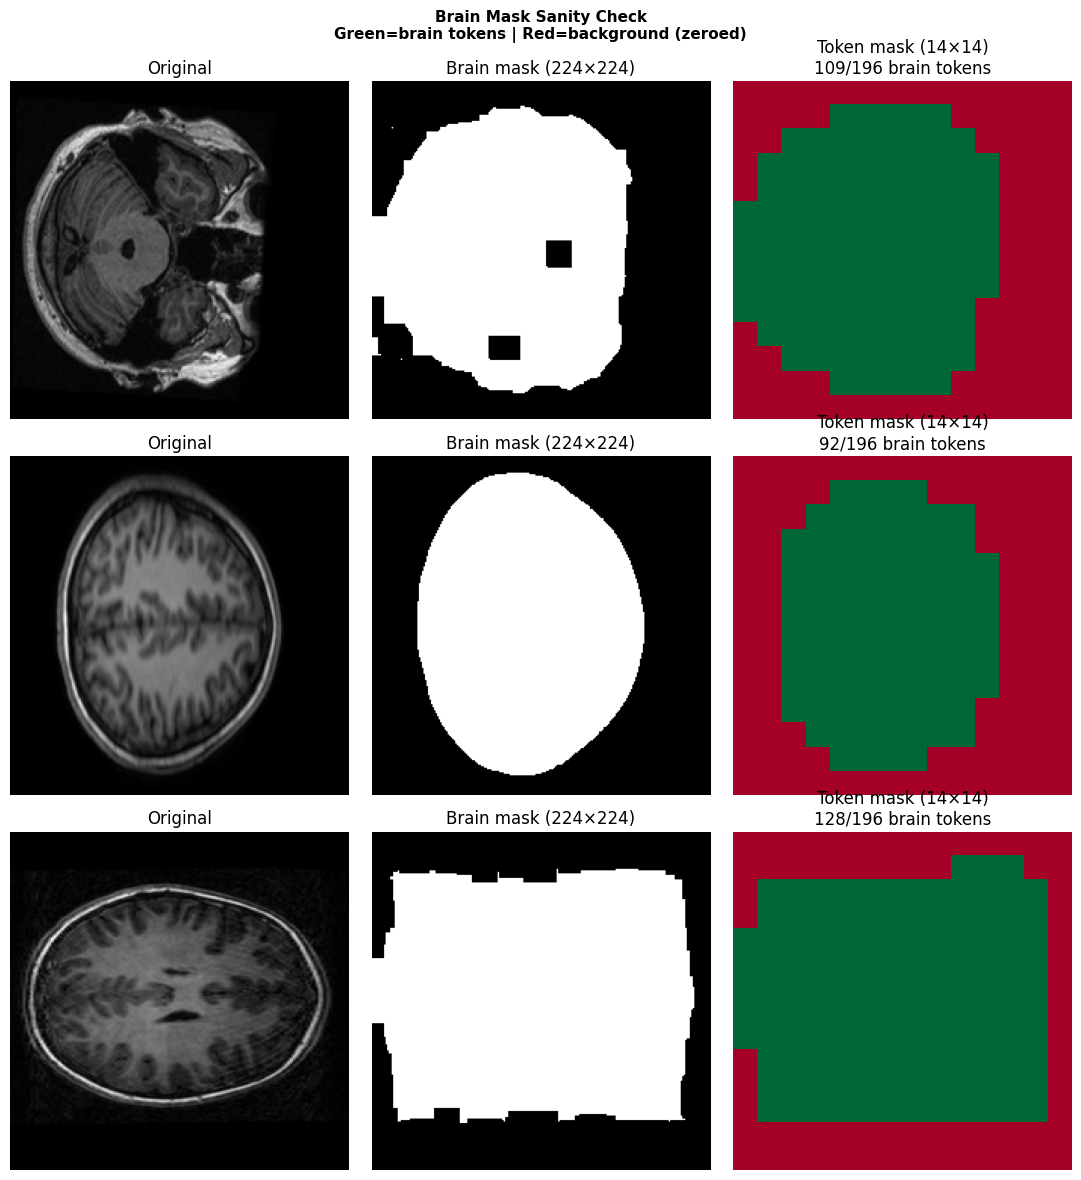

In [6]:
def generate_brain_mask(img_tensor):
    """
    Binary brain mask from normalised input tensor.
    Args: img_tensor (B,3,H,W) — normalised
    Returns: mask (B,1,H,W) float {0,1}
    """
    gray = img_tensor.mean(dim=1, keepdim=True)          # (B,1,H,W)
    gray_orig = (gray * STD[0] + MEAN[0]).clamp(0,1)    # approximate denorm
    mask = (gray_orig > MASK_THRESHOLD).float()

    # Morphological closing to fill holes — per sample, numpy
    kernel = np.ones((15,15), np.uint8)
    closed = []
    for b in range(mask.shape[0]):
        m = mask[b,0].cpu().numpy().astype(np.uint8)
        closed.append(torch.from_numpy(
            cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)).float())
    return torch.stack(closed).unsqueeze(1).to(img_tensor.device)  # (B,1,H,W)


def mask_to_tokens(mask, fs=FEAT_SIZE):
    """
    Downsample mask (B,1,H,W) → token mask (B, N_tokens) bool.
    Tokens with >30% brain coverage are marked as brain.
    """
    down = F.adaptive_avg_pool2d(mask, (fs,fs))
    tok  = (down > 0.3).squeeze(1)              # (B,fs,fs)
    return tok.reshape(tok.shape[0],-1)          # (B, N_tokens)


# Visual sanity check
def vis_masks(csv_path, n=3):
    df=pd.read_csv(csv_path)
    tf_=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
    fig,axes=plt.subplots(n,3,figsize=(11,4*n))
    shown=0
    for _,row in df.sample(frac=1,random_state=SEED).iterrows():
        if shown>=n: break
        p=row.iloc[1].replace('E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png',IMG_ROOT).replace('\\','/')
        try:
            pil=Image.open(p).convert('RGB').resize((224,224))
            t=tf_(pil).unsqueeze(0)
            mask=generate_brain_mask(t)
            tok=mask_to_tokens(mask)
            nb=tok[0].sum().item()
            if nb<MIN_BRAIN_TOKENS: continue
            axes[shown,0].imshow(np.array(pil)[:,:,0],cmap='gray'); axes[shown,0].axis('off')
            axes[shown,0].set_title('Original')
            axes[shown,1].imshow(mask[0,0].numpy(),cmap='gray',vmin=0,vmax=1); axes[shown,1].axis('off')
            axes[shown,1].set_title('Brain mask (224×224)')
            axes[shown,2].imshow(tok[0].reshape(FEAT_SIZE,FEAT_SIZE).numpy(),cmap='RdYlGn',vmin=0,vmax=1)
            axes[shown,2].set_title(f'Token mask (14×14)\n{int(nb)}/196 brain tokens')
            axes[shown,2].axis('off')
            shown+=1
        except: continue
    plt.suptitle('Brain Mask Sanity Check\nGreen=brain tokens | Red=background (zeroed)',fontsize=11,fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/brain_mask_check.png',dpi=130,bbox_inches='tight')
    plt.show()

vis_masks(VAL_CSV)

## 4. Dataset

In [7]:
class ASDDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data=pd.read_csv(csv_file); self.transform=transform
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p=(self.data.iloc[i,1]
           .replace('E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png',IMG_ROOT)
           .replace('\\','/'))
        img=Image.open(p).convert('RGB'); lbl=int(self.data.iloc[i,3])
        return self.transform(img) if self.transform else img, lbl

train_tf=transforms.Compose([transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),transforms.ColorJitter(brightness=0.05,contrast=0.05),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
eval_tf=transforms.Compose([transforms.Resize((224,224)),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

train_ds=ASDDataset(TRAIN_CSV,train_tf); val_ds=ASDDataset(VAL_CSV,eval_tf); test_ds=ASDDataset(TEST_CSV,eval_tf)
train_loader=DataLoader(train_ds,BATCH_SIZE,shuffle=True, num_workers=2,pin_memory=True)
val_loader  =DataLoader(val_ds,  BATCH_SIZE,shuffle=False,num_workers=2)
test_loader =DataLoader(test_ds, BATCH_SIZE,shuffle=False,num_workers=2)
print(f'Train:{len(train_ds):,} Val:{len(val_ds):,} Test:{len(test_ds):,}')

Train:67,625 Val:7,507 Test:18,814


## 5. Model Architecture

### CNN Backbone (conv1–conv4)

Extracts the first four blocks from Phase 2 `ASDClassifierCNN`. `conv5` and the FC classifier head are discarded — replaced by the transformer.

**Two-phase training strategy:**
- Phase 1 (epochs 1–5, backbone frozen): transformer initialises against stable fixed features
- Phase 2 (epochs 6–30, backbone unfrozen with lr=2e-5): joint fine-tuning with 10× lower backbone LR

### Positional Embeddings

2D sinusoidal embeddings encode row and column independently for the 14×14 grid, making spatial structure explicit without learnable parameters. The CLS token gets a separate learnable positional embedding.

### Transformer Encoder

Pre-LN (LayerNorm before attention) blocks — more stable than Post-LN for small-data regimes. Attention weights from the last layer's CLS→token rows provide spatial interpretability.

In [8]:
class CNNBackbone(nn.Module):
    """conv1–conv4 from Phase 2. Output: (B,128,14,14)."""
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,16,3,padding=1);   self.lrelu1=nn.LeakyReLU(0.1)
        self.pool1=nn.MaxPool2d(2,2);              self.drop1=nn.Dropout2d(0.2)
        self.conv2=nn.Conv2d(16,32,3,padding=1);  self.lrelu2=nn.LeakyReLU(0.1)
        self.bn1=nn.BatchNorm2d(32);               self.pool2=nn.MaxPool2d(2,2)
        self.drop2=nn.Dropout2d(0.2)
        self.conv3=nn.Conv2d(32,64,3,padding=1);  self.lrelu3=nn.LeakyReLU(0.1)
        self.bn2=nn.BatchNorm2d(64);               self.pool3=nn.MaxPool2d(2,2)
        self.drop3=nn.Dropout2d(0.2)
        self.conv4=nn.Conv2d(64,128,3,padding=1); self.lrelu4=nn.LeakyReLU(0.1)
        self.bn3=nn.BatchNorm2d(128);              self.pool4=nn.MaxPool2d(2,2)
        self.drop4=nn.Dropout2d(0.2)

    def forward(self,x):
        x=self.drop1(self.pool1(self.lrelu1(self.conv1(x))))
        x=self.drop2(self.pool2(self.bn1(self.lrelu2(self.conv2(x)))))
        x=self.drop3(self.pool3(self.bn2(self.lrelu3(self.conv3(x)))))
        return self.drop4(self.pool4(self.bn3(self.lrelu4(self.conv4(x)))))

    def load_phase2(self, path):
        state=torch.load(path,map_location='cpu')
        my_keys=set(self.state_dict().keys())
        filtered={k:v for k,v in state.items() if k in my_keys}
        self.load_state_dict(filtered,strict=False)
        print(f'  Loaded {len(filtered)}/{len(my_keys)} keys from Phase 2 weights')

    def freeze(self):   [p.__setattr__('requires_grad',False) for p in self.parameters()]; print('  Backbone frozen')
    def unfreeze(self): [p.__setattr__('requires_grad',True)  for p in self.parameters()]; print('  Backbone unfrozen')

In [9]:
def sinusoidal_2d_pos_emb(fs, ed):
    """(1, fs*fs, ed) 2D sinusoidal positional embedding."""
    hd=ed//2
    scale=math.log(10000)/(hd//2-1)
    emb=torch.exp(torch.arange(hd//2)*-scale)
    def enc(pos): return torch.cat([torch.sin(pos*emb),torch.cos(pos*emb)],dim=1)
    rows=torch.arange(fs).float().unsqueeze(1); cols=torch.arange(fs).float().unsqueeze(1)
    re,ce=enc(rows),enc(cols)  # (fs,hd) each
    pe=[torch.cat([re[r],ce[c]]) for r in range(fs) for c in range(fs)]
    return torch.stack(pe).unsqueeze(0)  # (1,N,ed)


class TransformerBlock(nn.Module):
    """Pre-LN encoder block. Stores attention weights for visualisation."""
    def __init__(self,ed,nh,ff,dr=0.1):
        super().__init__()
        self.n1=nn.LayerNorm(ed); self.attn=nn.MultiheadAttention(ed,nh,dropout=dr,batch_first=True)
        self.n2=nn.LayerNorm(ed)
        self.ffn=nn.Sequential(nn.Linear(ed,ff),nn.GELU(),nn.Dropout(dr),nn.Linear(ff,ed),nn.Dropout(dr))
        self.attn_w=None
    def forward(self,x):
        xn=self.n1(x); ao,aw=self.attn(xn,xn,xn,need_weights=True,average_attn_weights=False)
        self.attn_w=aw.detach()  # (B,nh,seq,seq)
        x=x+ao; x=x+self.ffn(self.n2(x)); return x

In [10]:
class HybridCNNViT(nn.Module):
    """
    Hybrid CNN-ViT for ASD classification.
    Forward: brain_mask → CNN backbone → token masking → projection →
             positional emb → CLS + transformer → classify
    Interpretability: get_attention_rollout() returns (B,196) CLS→token attention
    """
    def __init__(self,cnn_out=CNN_OUT_CH,fs=FEAT_SIZE,ed=EMBED_DIM,nh=N_HEADS,nl=N_LAYERS,ff=FF_DIM,dr=DROPOUT):
        super().__init__()
        self.fs=fs; self.nt=fs*fs; self.ed=ed
        self.backbone   = CNNBackbone()
        self.token_proj = nn.Sequential(nn.Linear(cnn_out,ed),nn.LayerNorm(ed))
        pe=sinusoidal_2d_pos_emb(fs,ed)
        self.register_buffer('pos_emb',pe)             # (1,196,ed)
        self.cls_tok=nn.Parameter(torch.zeros(1,1,ed))
        self.cls_pe =nn.Parameter(torch.zeros(1,1,ed))
        nn.init.trunc_normal_(self.cls_tok,std=0.02); nn.init.trunc_normal_(self.cls_pe,std=0.02)
        self.transformer=nn.ModuleList([TransformerBlock(ed,nh,ff,dr) for _ in range(nl)])
        self.norm=nn.LayerNorm(ed); self.head=nn.Linear(ed,2)
        self.drop=nn.Dropout(dr)

    def forward(self,x):
        B=x.shape[0]
        # Brain mask
        mask=generate_brain_mask(x)                        # (B,1,224,224)
        tok_mask=mask_to_tokens(mask).float().unsqueeze(-1) # (B,196,1)
        # CNN features
        feat=self.backbone(x)                              # (B,128,14,14)
        # Reshape to tokens, apply mask
        tokens=feat.permute(0,2,3,1).reshape(B,self.nt,-1) # (B,196,128)
        tokens=tokens*tok_mask                             # zero background
        # Project
        tokens=self.drop(self.token_proj(tokens))+self.pos_emb  # (B,196,ed)
        # CLS
        cls=(self.cls_tok+self.cls_pe).expand(B,-1,-1)
        tokens=torch.cat([cls,tokens],dim=1)               # (B,197,ed)
        # Transformer
        for i,blk in enumerate(self.transformer): tokens=blk(tokens)
        return self.head(self.norm(tokens[:,0]))

    def get_cls_attn(self):
        """CLS→token attention from last layer, head-averaged, normalised. (B,196)"""
        aw=self.transformer[-1].attn_w  # (B,nh,197,197)
        if aw is None: return None
        ca=aw[:,:,0,1:].mean(dim=1)    # (B,196)
        mn,mx=ca.min(1,keepdim=True)[0],ca.max(1,keepdim=True)[0]
        return (ca-mn)/(mx-mn+1e-8)


model=HybridCNNViT().to(device)
print('Loading Phase 2 backbone weights...')
model.backbone.load_phase2(CNN_WEIGHTS)
tp=sum(p.numel() for p in model.parameters())
bp=sum(p.numel() for p in model.backbone.parameters())
tp_=sum(p.numel() for p in model.transformer.parameters())
print(f'\nParam breakdown:')
print(f'  Backbone    : {bp:>10,}  (conv1-4, Phase 2 init)')
print(f'  Transformer : {tp_:>10,}  ({N_LAYERS} layers dim={EMBED_DIM} heads={N_HEADS})')
print(f'  Total       : {tp:>10,}')
_x=torch.randn(2,3,224,224).to(device)
assert model(_x).shape==(2,2); del _x; torch.cuda.empty_cache() if device.type=='cuda' else None
print('Forward pass sanity check passed.')

Loading Phase 2 backbone weights...
  Loaded 23/23 keys from Phase 2 weights

Param breakdown:
  Backbone    :     97,888  (conv1-4, Phase 2 init)
  Transformer :  2,108,416  (4 layers dim=256 heads=8)
  Total       :  2,241,378
Forward pass sanity check passed.


## 6. Training

**Key differences from B.Tech ViT attempts:**

| Component | B.Tech (wrong) | This notebook (correct) |
|---|---|---|
| LR (pretrained) | 1e-3 (too high, destroys weights) | 2e-5 backbone / 2e-4 transformer |
| Epochs (pretrained) | 3 | 30 with early stopping |
| LR schedule | none | cosine warmup |
| Backbone phase | none | frozen 5ep then unfrozen |
| Loss | BCEWithLogitsLoss + squeeze | CrossEntropyLoss (2 classes) |
| Grad clipping | none | clip_norm=1.0 (critical for transformers) |

In [11]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    probs,preds,labs=[],[],[]
    tl=0.0; crit=nn.CrossEntropyLoss()
    for imgs,lbl in loader:
        imgs,lbl=imgs.to(device),lbl.to(device)
        lo=model(imgs); tl+=crit(lo,lbl).item()
        p=F.softmax(lo,dim=1)[:,1]
        probs.extend(p.cpu().numpy()); preds.extend((p>=0.5).cpu().numpy()); labs.extend(lbl.cpu().numpy())
    t,p,pr=np.array(labs),np.array(preds),np.array(probs)
    cm=confusion_matrix(t,p,labels=[0,1])
    tn,fp,fn,tp_=cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
    return dict(loss=tl/len(loader),AUC=roc_auc_score(t,pr),Accuracy=accuracy_score(t,p),
                Sensitivity=tp_/(tp_+fn) if tp_+fn>0 else 0,
                Specificity=tn/(tn+fp) if tn+fp>0 else 0,F1=f1_score(t,p,zero_division=0))

In [12]:
model.backbone.freeze()  # Phase 1: start with frozen backbone

# Differential LR param groups
bb_params  = list(model.backbone.parameters())
oth_params = [p for n,p in model.named_parameters() if not n.startswith('backbone.')]

optimizer = optim.AdamW(
    [{'params':bb_params,'lr':LR_BACKBONE,'name':'backbone'},
     {'params':oth_params,'lr':LR_TRANSFORMER,'name':'transformer'}],
    weight_decay=WEIGHT_DECAY)

# Warmup then cosine
warmup = optim.lr_scheduler.LinearLR(optimizer,start_factor=0.01,end_factor=1.0,total_iters=WARMUP_EPOCHS)
cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=TOTAL_EPOCHS-WARMUP_EPOCHS,eta_min=1e-6)
criterion = nn.CrossEntropyLoss().to(device)

history={'tl':[],'vl':[],'ta':[],'va':[],'ts':[],'vs':[],'lrt':[],'lrb':[],'phase':[]}
best_val_auc=0.0; patience_c=0; bb_unfrozen=False
BEST_PATH=f'{OUT_DIR}/hybrid_best.pth'

print(f'Training {TOTAL_EPOCHS} epochs | backbone unfreezes at ep {FREEZE_EPOCHS+1}')
t0=time.time()

for ep in range(1,TOTAL_EPOCHS+1):
    # Phase transition
    if ep==FREEZE_EPOCHS+1 and not bb_unfrozen:
        model.backbone.unfreeze()
        for pg in optimizer.param_groups:
            if pg['name']=='backbone':
                for p in pg['params']: p.requires_grad=True
        bb_unfrozen=True; print(f'\n  Ep {ep}: backbone unfrozen — joint fine-tuning')

    phase='frozen' if not bb_unfrozen else 'joint'

    # Train
    model.train(); tl=0.0; tp_,tlab=[],[]
    for imgs,lbl in tqdm(train_loader,desc=f'Ep{ep:2d}[{phase[:3]}]',leave=False):
        imgs,lbl=imgs.to(device),lbl.to(device)
        optimizer.zero_grad(); lo=model(imgs); loss=criterion(lo,lbl); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)  # critical for transformers
        optimizer.step()
        tl+=loss.item()
        with torch.no_grad(): p=F.softmax(lo.detach(),dim=1)[:,1]
        tp_.extend(p.cpu().numpy()); tlab.extend(lbl.cpu().numpy())

    if ep<=WARMUP_EPOCHS: warmup.step()
    else: cosine.step()

    ta=roc_auc_score(tlab,tp_)
    ts=sum((np.array(tp_)>=0.5)&(np.array(tlab)==1))/max(sum(np.array(tlab)==1),1)
    vm=evaluate(model,val_loader)
    if device.type=='cuda': torch.cuda.empty_cache()

    history['tl'].append(tl/len(train_loader)); history['vl'].append(vm['loss'])
    history['ta'].append(ta); history['va'].append(vm['AUC'])
    history['ts'].append(ts); history['vs'].append(vm['Sensitivity'])
    history['lrt'].append(optimizer.param_groups[1]['lr'])
    history['lrb'].append(optimizer.param_groups[0]['lr'])
    history['phase'].append(phase)

    print(f'  Ep{ep:2d}[{phase[:3]}] TrainAUC={ta:.4f} Sens={ts:.4f} | '
          f'ValAUC={vm["AUC"]:.4f} Sens={vm["Sensitivity"]:.4f} Spec={vm["Specificity"]:.4f} | '
          f'lr_t={optimizer.param_groups[1]["lr"]:.1e}')

    if vm['AUC']>best_val_auc+0.0005:
        best_val_auc=vm['AUC']; patience_c=0
        torch.save(model.state_dict(),BEST_PATH); print(f'    ✓ Best val AUC: {best_val_auc:.4f}')
    else:
        patience_c+=1
        if patience_c>=PATIENCE and bb_unfrozen:
            print(f'  Early stopping ep {ep}'); break

print(f'\nTraining done in {(time.time()-t0)/60:.1f} min. Best val AUC: {best_val_auc:.4f}')
torch.save(model.state_dict(),f'{OUT_DIR}/hybrid_final.pth')
model.load_state_dict(torch.load(BEST_PATH,map_location=device)); model.eval()
os.makedirs('/content/drive/MyDrive/ASD_Phase3B',exist_ok=True)
shutil.copy(BEST_PATH,'/content/drive/MyDrive/ASD_Phase3B/hybrid_best.pth')
print('Saved to Drive.')

  Backbone frozen
Training 30 epochs | backbone unfreezes at ep 6


  Ep 1[fro] TrainAUC=0.5287 Sens=0.4662 | ValAUC=0.5529 Sens=0.3669 Spec=0.7121 | lr_t=6.8e-05
    ✓ Best val AUC: 0.5529


  Ep 2[fro] TrainAUC=0.5581 Sens=0.4859 | ValAUC=0.6007 Sens=0.4872 Spec=0.6617 | lr_t=1.3e-04
    ✓ Best val AUC: 0.6007


  Ep 3[fro] TrainAUC=0.5868 Sens=0.4648 | ValAUC=0.6292 Sens=0.7396 Spec=0.4170 | lr_t=2.0e-04
    ✓ Best val AUC: 0.6292


  Ep 4[fro] TrainAUC=0.5999 Sens=0.4790 | ValAUC=0.6264 Sens=0.1881 Spec=0.9379 | lr_t=2.0e-04


...

  Ep26[joi] TrainAUC=0.9001 Sens=0.7916 | ValAUC=0.9368 Sens=0.8297 Spec=0.8678 | lr_t=1.2e-05
    ✓ Best val AUC: 0.9368


  Ep27[joi] TrainAUC=0.9037 Sens=0.7937 | ValAUC=0.9415 Sens=0.8489 Spec=0.8650 | lr_t=7.0e-06
    ✓ Best val AUC: 0.9415


  Ep28[joi] TrainAUC=0.9059 Sens=0.8003 | ValAUC=0.9424 Sens=0.8569 Spec=0.8510 | lr_t=3.7e-06
    ✓ Best val AUC: 0.9424


  Ep29[joi] TrainAUC=0.9077 Sens=0.8015 | ValAUC=0.9439 Sens=0.8443 Spec=0.8689 | lr_t=1.7e-06
    ✓ Best val AUC: 0.9439


  Ep30[joi] TrainAUC=0.9095 Sens=0.8024 | ValAUC=0.9433 Sens=0.8572 Spec=0.8583 | lr_t=1.0e-06

Training done in 185.5 min. Best val AUC: 0.9439
Saved to Drive.


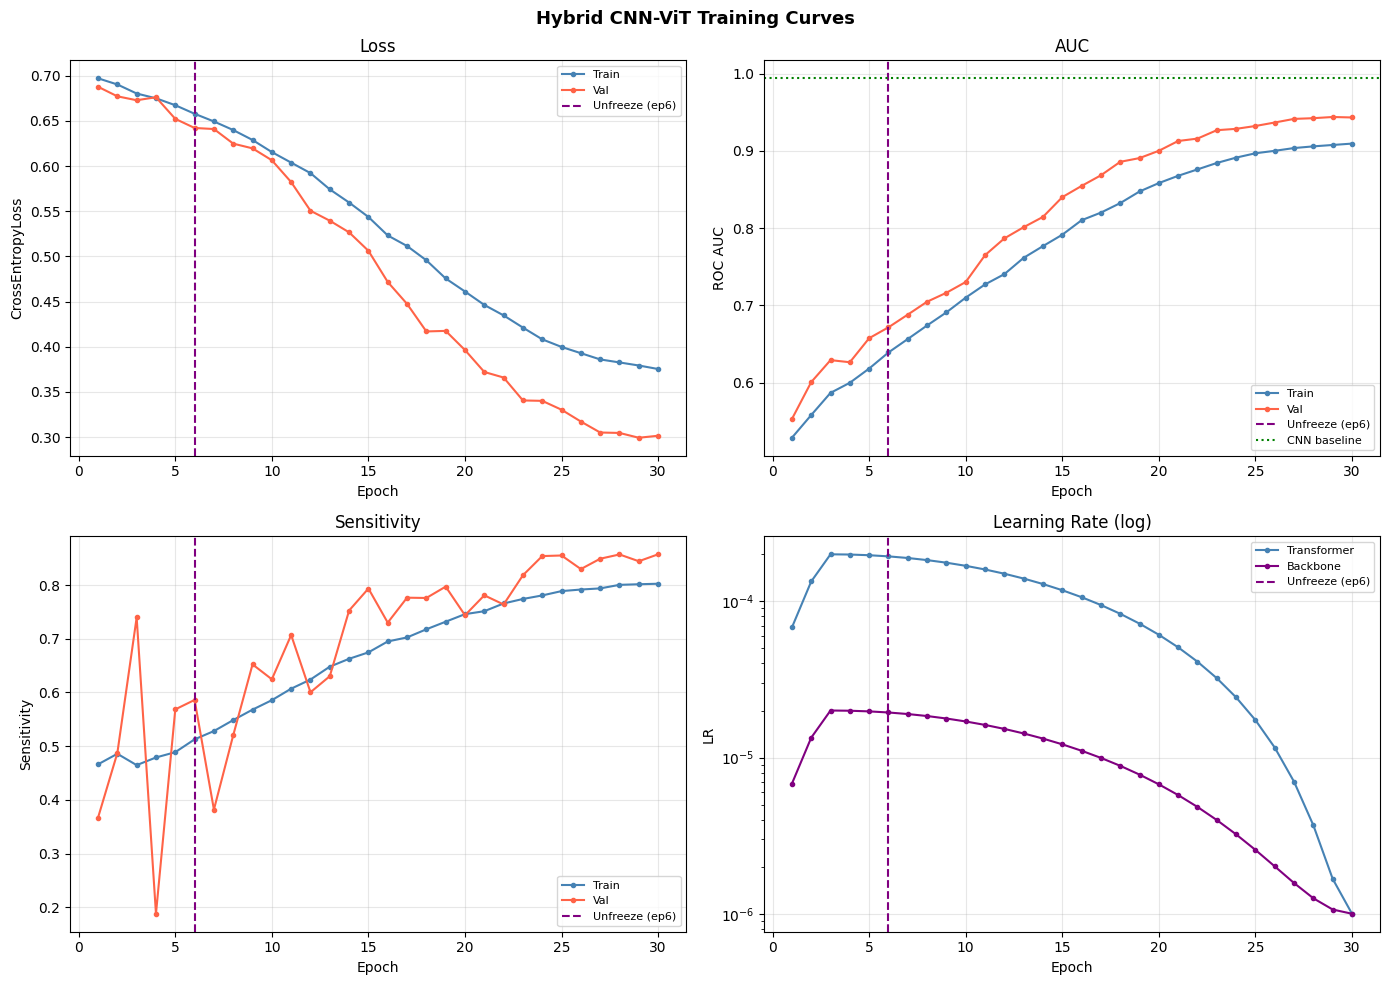

In [13]:
# Training curves
n=len(history['tl']); xs=range(1,n+1); ue=FREEZE_EPOCHS+1
fig,axes=plt.subplots(2,2,figsize=(14,10))
for ax,(tr,va,title,yl) in zip(axes.flatten(),[
    (history['tl'],history['vl'],'Loss','CrossEntropyLoss'),
    (history['ta'],history['va'],'AUC','ROC AUC'),
    (history['ts'],history['vs'],'Sensitivity','Sensitivity'),
    (history['lrt'],history['lrb'],'Learning Rate (log)','LR')]):
    ax.plot(xs,tr,'steelblue',marker='o',ms=3,label='Train' if title!='Learning Rate (log)' else 'Transformer')
    ax.plot(xs,va,'tomato' if title!='Learning Rate (log)' else 'purple',marker='o',ms=3,
            label='Val' if title!='Learning Rate (log)' else 'Backbone')
    ax.axvline(ue,color='purple',linestyle='--',lw=1.5,label=f'Unfreeze (ep{ue})')
    if title=='AUC': ax.axhline(0.994,color='green',linestyle=':',lw=1.5,label='CNN baseline')
    if title=='Learning Rate (log)': ax.set_yscale('log')
    ax.set(title=title,xlabel='Epoch',ylabel=yl); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Hybrid CNN-ViT Training Curves',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/training_curves.png',dpi=150,bbox_inches='tight'); plt.show()

## 7. Test Set Evaluation — CNN vs Hybrid CNN-ViT

In [14]:
hybrid_m=evaluate(model,test_loader)

# Additional metrics
model.eval(); ap_,al_=[],[]
with torch.no_grad():
    for imgs,lbl in test_loader:
        p=F.softmax(model(imgs.to(device)),dim=1)[:,1]
        ap_.extend(p.cpu().numpy()); al_.extend(lbl.numpy())
ap_,al_=np.array(ap_),np.array(al_)
auprc=average_precision_score(al_,ap_); brier=brier_score_loss(al_,ap_)

# CNN Phase 2 baseline
cnn_b={'AUC':0.9944,'Sensitivity':0.9560,'Specificity':0.9720,'F1':0.9510,'Accuracy':0.9500}

print(f'\n{"Metric":<18}{"CNN Phase2":>14}{"Hybrid ViT":>14}{"Δ":>12}')
print('-'*60)
for k in ['AUC','Sensitivity','Specificity','F1','Accuracy']:
    c=cnn_b[k]; h=hybrid_m[k]; d=h-c
    print(f'  {k:<16}{c:>14.4f}{h:>14.4f}{d:>+12.4f}')
print(f'\n  AUPRC : {auprc:.4f}  (CNN: 0.9943)')
print(f'  Brier : {brier:.4f}  (CNN: 0.0270)')


Metric                CNN Phase2    Hybrid ViT           Δ
------------------------------------------------------------
  AUC                     0.9944        0.9425     -0.0519
  Sensitivity             0.9560        0.8447     -0.1113
  Specificity             0.9720        0.8681     -0.1039
  F1                      0.9510        0.8516     -0.0994
  Accuracy                0.9500        0.8567     -0.0933

  AUPRC : 0.9440  (CNN: 0.9943)
  Brier : 0.0974  (CNN: 0.0270)


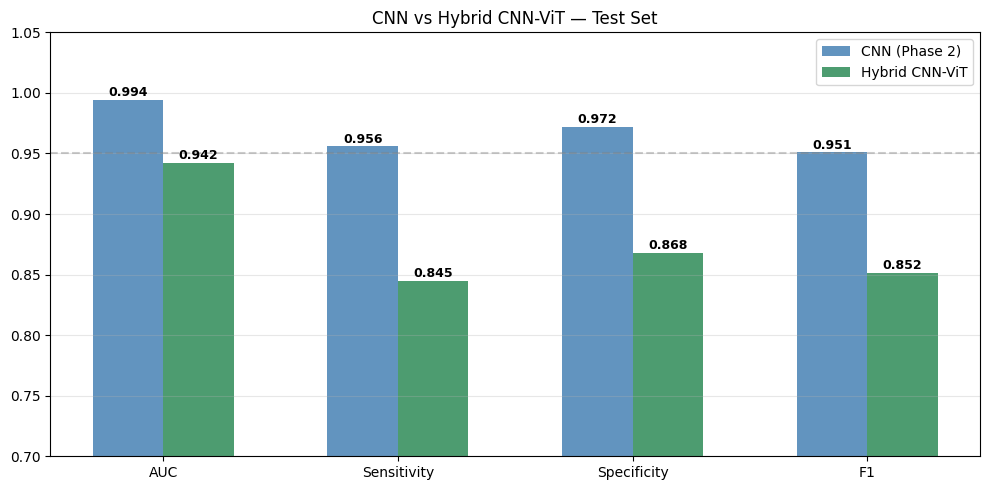

In [15]:
mn=['AUC','Sensitivity','Specificity','F1']
x=np.arange(4); w=0.3
fig,ax=plt.subplots(figsize=(10,5))
ax.bar(x-w/2,[cnn_b[m] for m in mn],w,label='CNN (Phase 2)',color='steelblue',alpha=0.85)
ax.bar(x+w/2,[hybrid_m[m] for m in mn],w,label='Hybrid CNN-ViT',color='seagreen',alpha=0.85)
ax.axhline(0.95,color='gray',linestyle='--',alpha=0.4)
ax.set(title='CNN vs Hybrid CNN-ViT — Test Set',xticks=x,xticklabels=mn,ylim=[0.7,1.05])
for bars,vals in zip(ax.containers,[[cnn_b[m] for m in mn],[hybrid_m[m] for m in mn]]):
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.003,f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
ax.legend(); ax.grid(alpha=0.3,axis='y')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/cnn_vs_hybrid.png',dpi=150,bbox_inches='tight'); plt.show()

## 8. Attention Map Visualisation

This is the core interpretability contribution of the hybrid architecture. The CLS token's attention to each of the 196 spatial tokens — averaged across 8 heads — answers: *which brain regions does the model weight when making its ASD/TC decision?*

We compare this directly with GradCAM on the same slices in Section 9.

Selecting showcase slices...
  TP: 1 found
  TN: 1 found
  FP: 1 found
  FN: 1 found


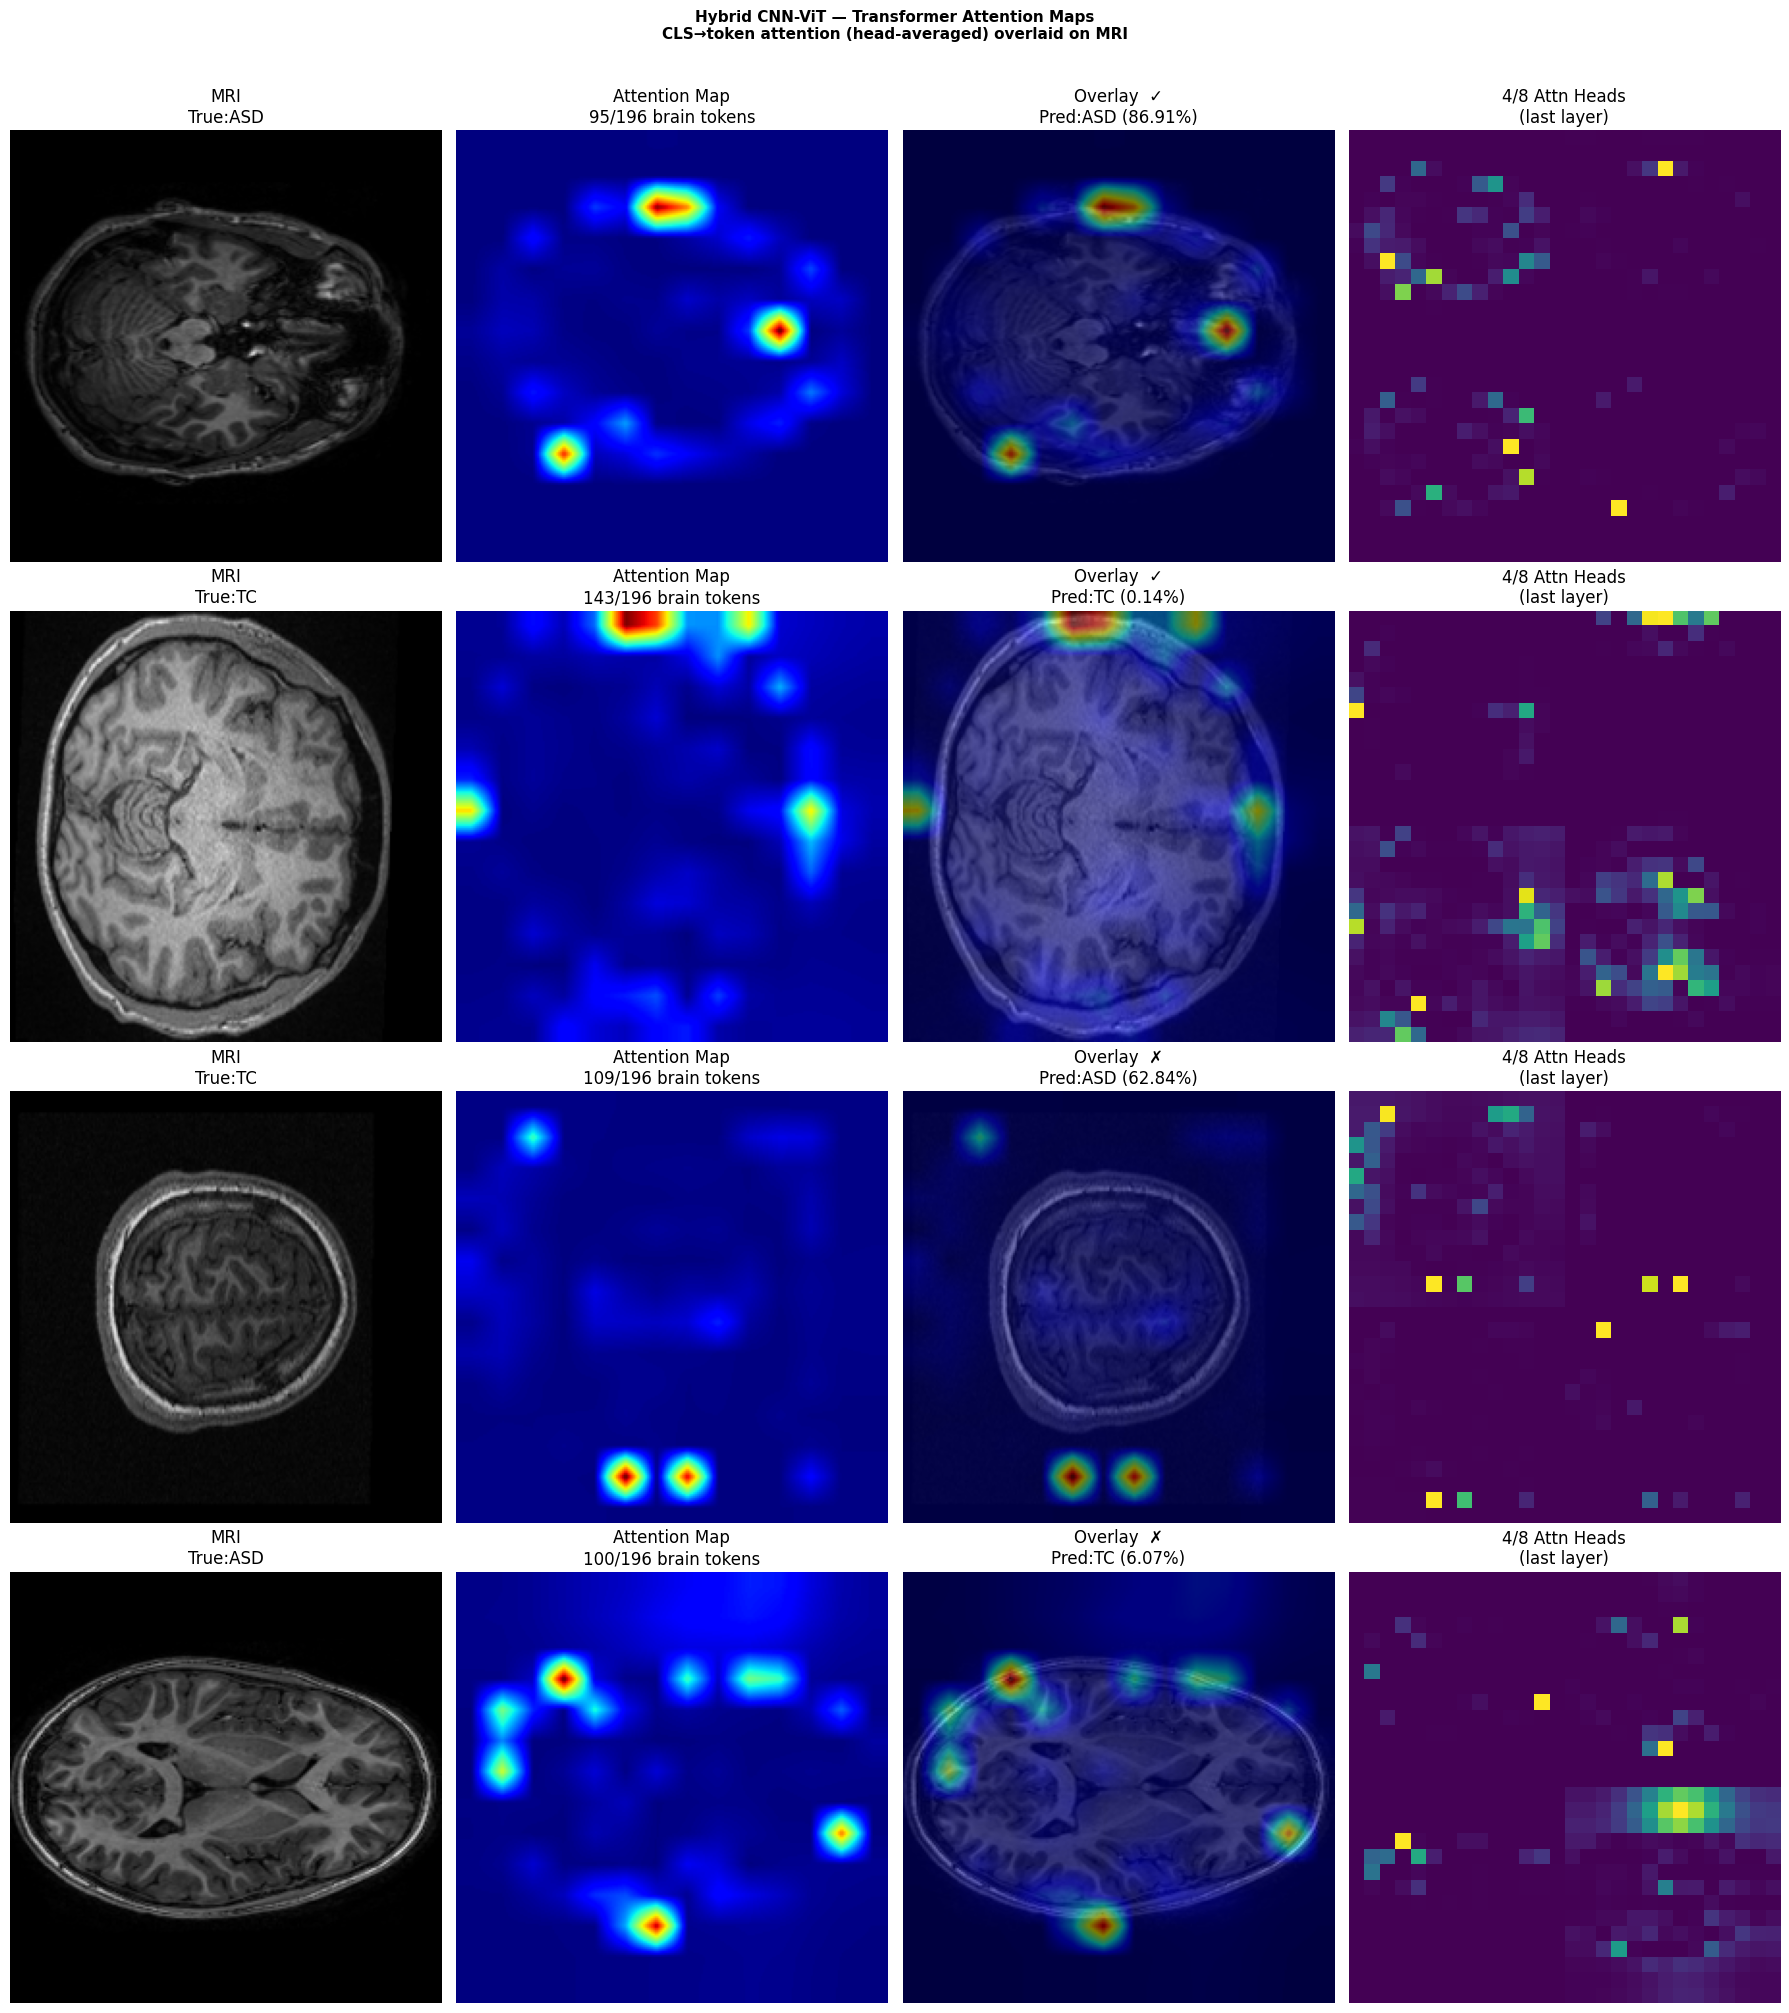

In [16]:
def attn_overlay(model, path, true_lbl):
    """Single forward pass → (orig, attn_224, overlay, pred, conf, n_brain_tokens)."""
    pil=Image.open(path).convert('RGB').resize((224,224))
    orig=np.array(pil).astype(np.float32)/255.0
    t=eval_tf(pil).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad(): lo=model(t); conf=F.softmax(lo,dim=1)[0,1].item(); pred=int(conf>=0.5)
    ca=model.get_cls_attn()  # (1,196)
    if ca is None: return orig,np.zeros((224,224)),(orig*255).astype(np.uint8),pred,conf,0
    ag=ca[0].cpu().numpy().reshape(FEAT_SIZE,FEAT_SIZE)
    a224=cv2.resize(ag,(224,224),interpolation=cv2.INTER_LINEAR)
    a224=(a224-a224.min())/(a224.max()-a224.min()+1e-8)
    hm=cm_mod.get_cmap('jet')(a224)[:,:,:3]
    ov=(0.5*orig+0.5*hm).clip(0,1)
    mask=generate_brain_mask(t); tm=mask_to_tokens(mask); nb=int(tm[0].sum().item())
    return orig,a224,(ov*255).astype(np.uint8),pred,conf,nb

def sample_by_outcome(csv,n=1,min_b=0.06):
    df=pd.read_csv(csv); out={'TP':[],'TN':[],'FP':[],'FN':[]}
    model.eval()
    for _,row in df.sample(frac=1,random_state=SEED).iterrows():
        if all(len(v)>=n for v in out.values()): break
        p=row.iloc[1].replace('E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png',IMG_ROOT).replace('\\','/')
        lbl=int(row.iloc[3])
        try:
            a=np.array(Image.open(p).convert('L'))/255.0
            if a.mean()<min_b or (a>0.05).mean()<0.15: continue
            t_=eval_tf(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad(): c_=F.softmax(model(t_),dim=1)[0,1].item()
            pr=int(c_>=0.5)
            k='TP' if lbl==1 and pr==1 else 'TN' if lbl==0 and pr==0 else 'FP' if lbl==0 and pr==1 else 'FN'
            if len(out[k])<n: out[k].append((p,lbl,pr,c_))
        except: continue
    return out

print('Selecting showcase slices...')
showcase=sample_by_outcome(TEST_CSV,n=1)
for k,v in showcase.items(): print(f'  {k}: {len(v)} found')

CLSN={0:'TC',1:'ASD'}
PRETTY={'TP':'True Positive (ASD detected)','TN':'True Negative (TC cleared)',
        'FP':'False Positive (TC flagged)','FN':'False Negative (ASD missed)'}

cases=[(k,showcase[k][0]) for k in ['TP','TN','FP','FN'] if showcase[k]]
n=len(cases)
fig,axes=plt.subplots(n,4,figsize=(18,5*n))
if n==1: axes=axes[np.newaxis,:]
attn_data={}
for row,(outcome,(path,tl,pl,prob)) in enumerate(cases):
    orig,a224,ov,pred,conf,nb=attn_overlay(model,path,tl)
    attn_data[outcome]=(orig,a224,ov,tl,pred,conf,path,nb)
    aw=model.transformer[-1].attn_w  # (1,8,197,197)
    axes[row,0].imshow(orig); axes[row,0].axis('off'); axes[row,0].set_title(f'MRI\nTrue:{CLSN[tl]}')
    axes[row,1].imshow(a224,cmap='jet',vmin=0,vmax=1); axes[row,1].axis('off')
    axes[row,1].set_title(f'Attention Map\n{nb}/196 brain tokens')
    status='✓' if pred==tl else '✗'
    axes[row,2].imshow(ov); axes[row,2].axis('off')
    axes[row,2].set_title(f'Overlay  {status}\nPred:{CLSN[pred]} ({conf:.2%})')
    if aw is not None:
        hg=np.zeros((FEAT_SIZE*2,FEAT_SIZE*2))
        for hi in range(4):
            ha=aw[0,hi,0,1:].cpu().numpy().reshape(FEAT_SIZE,FEAT_SIZE)
            ha=(ha-ha.min())/(ha.max()-ha.min()+1e-8)
            r_,c_=hi//2,hi%2
            hg[r_*FEAT_SIZE:(r_+1)*FEAT_SIZE,c_*FEAT_SIZE:(c_+1)*FEAT_SIZE]=ha
        axes[row,3].imshow(hg,cmap='viridis'); axes[row,3].set_title('4/8 Attn Heads\n(last layer)')
        axes[row,3].axis('off')
    axes[row,0].set_ylabel(PRETTY.get(outcome,''),fontsize=9,rotation=0,labelpad=130,va='center',style='italic')
plt.suptitle('Hybrid CNN-ViT — Transformer Attention Maps\nCLS→token attention (head-averaged) overlaid on MRI',
             fontsize=11,fontweight='bold',y=1.01)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/attention_maps.png',dpi=150,bbox_inches='tight'); plt.show()

## 9. GradCAM vs Attention Rollout Comparison

This is the headline interpretability figure. Both methods explain the same prediction on the same slice. Agreement (IoU, Pearson r) tells us whether gradient-based and attention-based explanations converge on the same neuroanatomical regions.

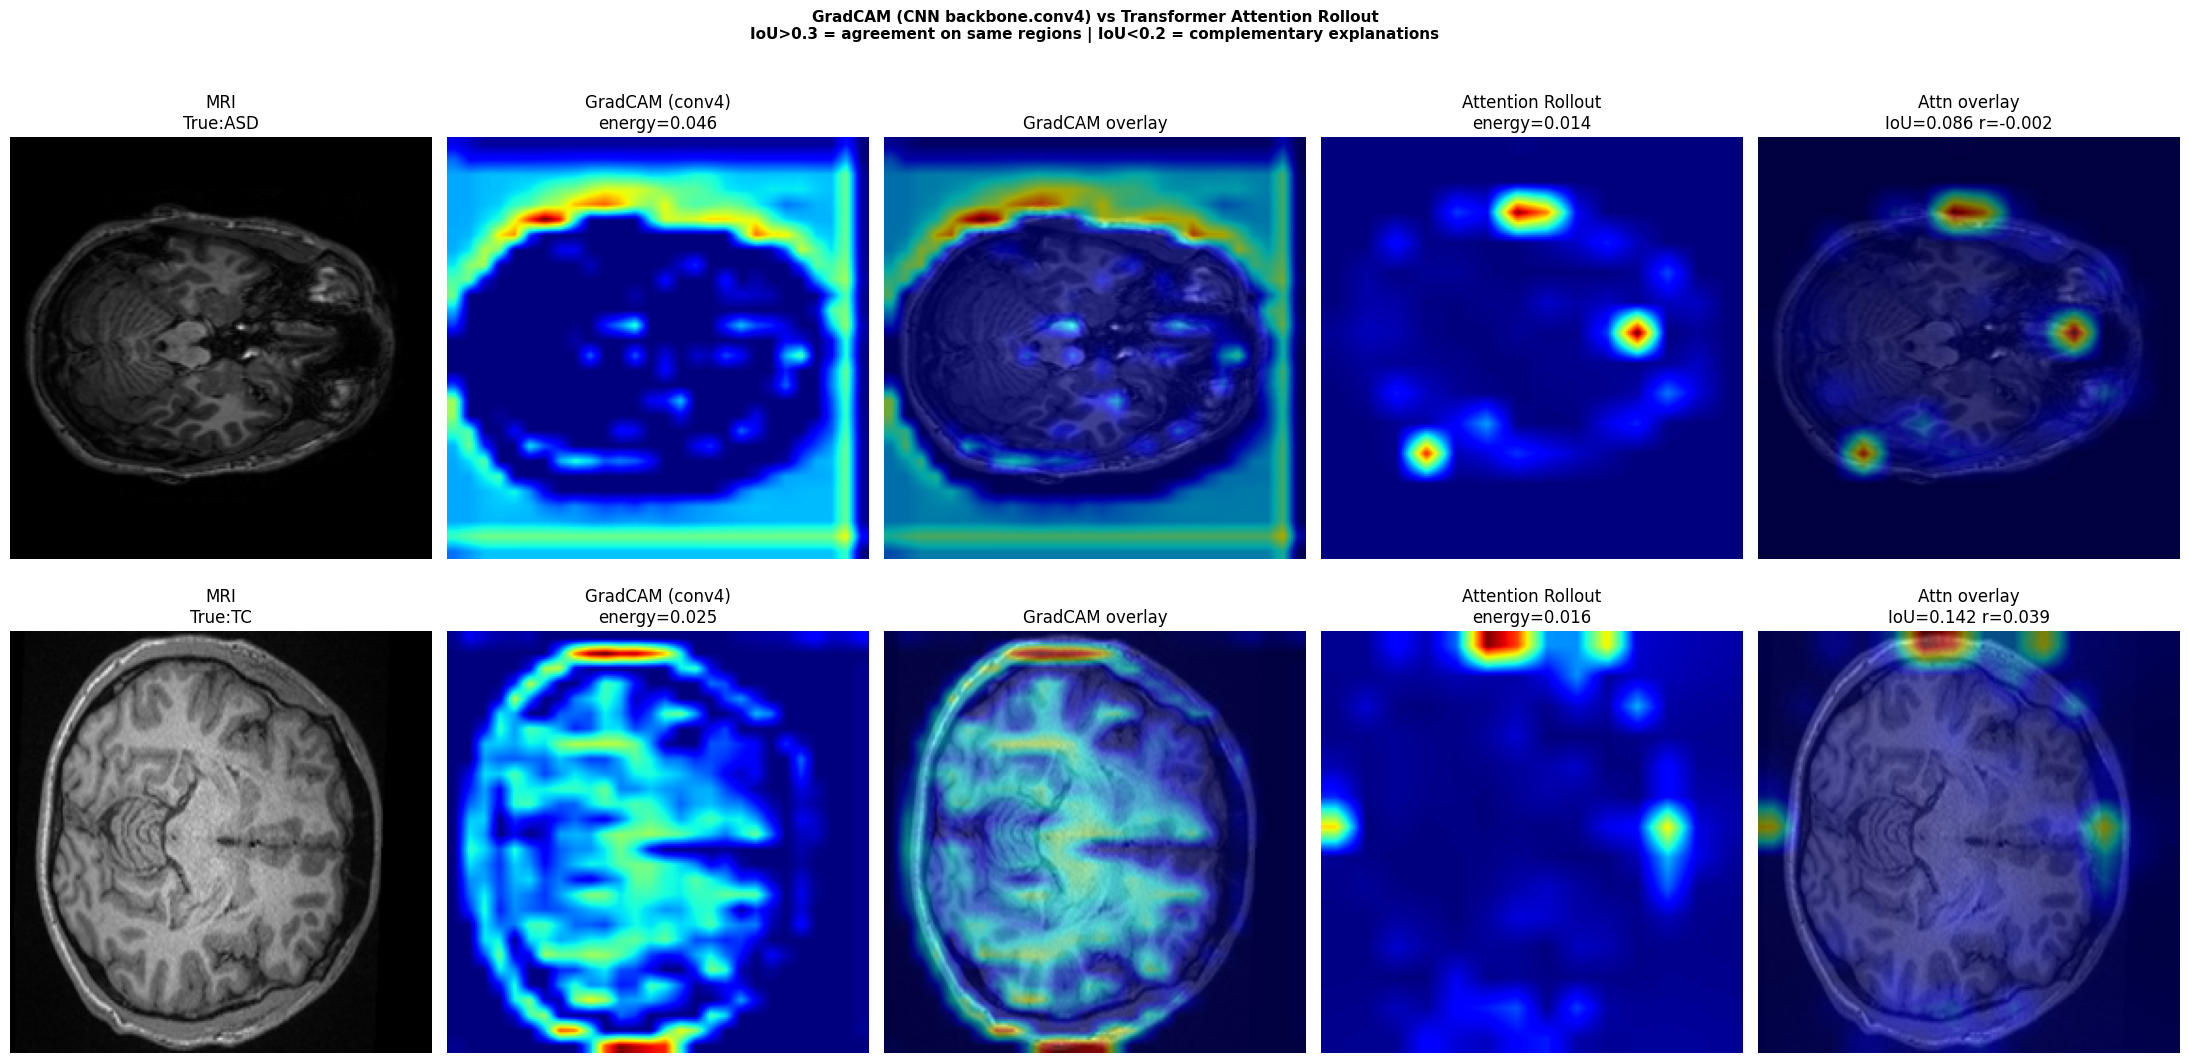

,True_,Pred,GC_energy,Attn_energy,IoU,Pearson_r,Brain_tokens
Outcome,,,,,,,
TP,ASD,ASD,0.0458,0.0138,0.0864,-0.0016,95
TN,TC,TC,0.0250,0.0157,0.1418,0.0392,143


In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from scipy.stats import pearsonr

def gc_backbone(model, path, cls):
    pil=Image.open(path).convert('RGB').resize((224,224))
    orig=np.array(pil).astype(np.float32)/255.0
    t=eval_tf(pil).unsqueeze(0).to(device)
    cam=GradCAM(model=model,target_layers=[model.backbone.conv4])
    gs=cam(t,[ClassifierOutputTarget(cls)])[0]
    ov=show_cam_on_image(orig,gs,use_rgb=True)
    return orig,gs,ov,float((gs>0.5).mean())

cmp_cases=[(k,showcase[k][0]) for k in ['TP','TN'] if showcase[k]]
fig,axes=plt.subplots(len(cmp_cases),5,figsize=(22,5.5*len(cmp_cases)))
if len(cmp_cases)==1: axes=axes[np.newaxis,:]
arows=[]
for row,(outcome,(path,tl,pl,prob)) in enumerate(cmp_cases):
    orig,go,gov,ge=gc_backbone(model,path,pl)
    _,a224,aov,pred,conf,nb=attn_overlay(model,path,tl)
    gc_hot=(go>=np.percentile(go,75)); at_hot=(a224>=np.percentile(a224,75))
    iou=(gc_hot&at_hot).sum()/((gc_hot|at_hot).sum()+1e-8)
    r,_=pearsonr(go.flatten(),a224.flatten())
    axes[row,0].imshow(orig); axes[row,0].axis('off'); axes[row,0].set_title(f'MRI\nTrue:{CLSN[tl]}')
    axes[row,1].imshow(go,cmap='jet',vmin=0,vmax=1); axes[row,1].axis('off')
    axes[row,1].set_title(f'GradCAM (conv4)\nenergy={ge:.3f}')
    axes[row,2].imshow(gov); axes[row,2].axis('off'); axes[row,2].set_title('GradCAM overlay')
    axes[row,3].imshow(a224,cmap='jet',vmin=0,vmax=1); axes[row,3].axis('off')
    axes[row,3].set_title(f'Attention Rollout\nenergy={(a224>0.5).mean():.3f}')
    axes[row,4].imshow(aov); axes[row,4].axis('off')
    axes[row,4].set_title(f'Attn overlay\nIoU={iou:.3f} r={r:.3f}')
    axes[row,0].set_ylabel(PRETTY.get(outcome,''),fontsize=9,rotation=0,labelpad=130,va='center')
    arows.append(dict(Outcome=outcome,True_=CLSN[tl],Pred=CLSN[pl],
                      GC_energy=round(ge,4),Attn_energy=round(float((a224>0.5).mean()),4),
                      IoU=round(float(iou),4),Pearson_r=round(float(r),4),Brain_tokens=nb))
plt.suptitle('GradCAM (CNN backbone.conv4) vs Transformer Attention Rollout\n'
             'IoU>0.3 = agreement on same regions | IoU<0.2 = complementary explanations',
             fontsize=11,fontweight='bold',y=1.01)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/gradcam_vs_attention.png',dpi=150,bbox_inches='tight'); plt.show()
ag_df=pd.DataFrame(arows)
display(ag_df.set_index('Outcome'))
ag_df.to_csv(f'{OUT_DIR}/gradcam_attn_agreement.csv',index=False)

## 10. MC-Dropout Uncertainty

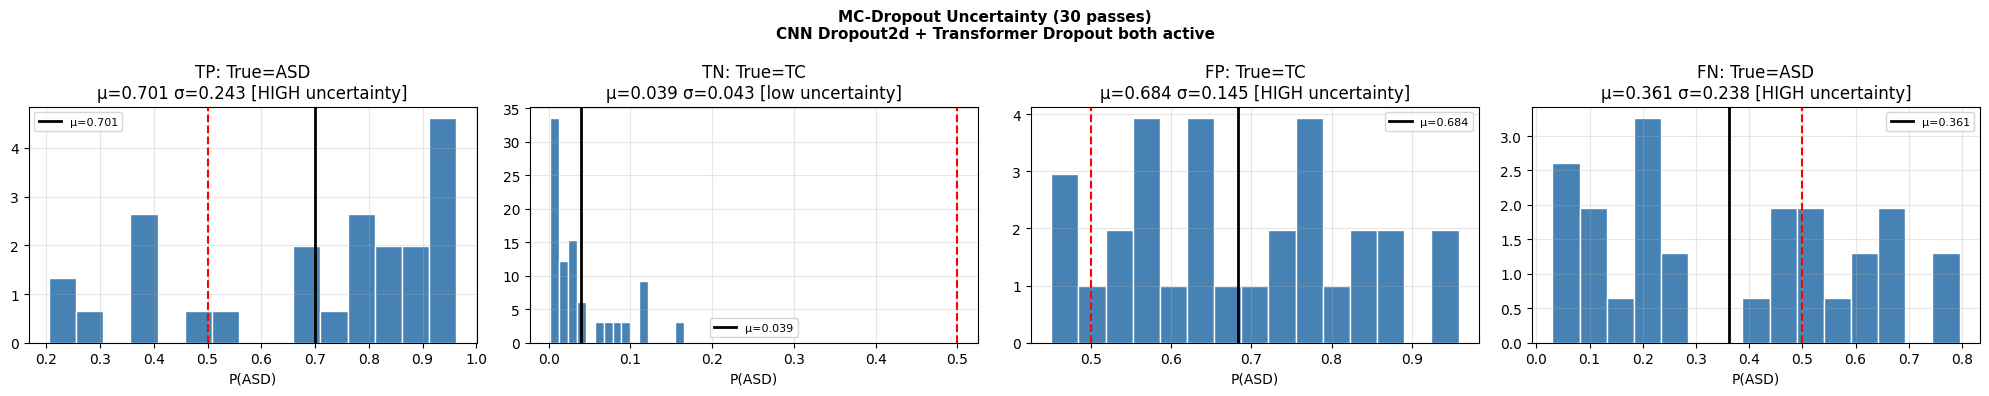

In [18]:
# Both CNN Dropout2d and Transformer Dropout are active during MC-Dropout
def enable_dropout(m):
    if isinstance(m,(nn.Dropout2d,nn.Dropout)): m.train()

def mc_predict(model,path,n=30):
    t=eval_tf(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
    model.eval(); model.apply(enable_dropout)
    with torch.no_grad():
        probs=[F.softmax(model(t),dim=1)[0,1].item() for _ in range(n)]
    model.eval(); return np.array(probs)

fig,axes=plt.subplots(1,len(cases),figsize=(5*len(cases),4))
if len(cases)==1: axes=[axes]
for ax,(outcome,(path,tl,pl,prob)) in zip(axes,cases):
    mc=mc_predict(model,path); mu,sig=mc.mean(),mc.std()
    ax.hist(mc,bins=15,color='steelblue',edgecolor='white',density=True)
    ax.axvline(0.5,color='red',linestyle='--',lw=1.5)
    ax.axvline(mu,color='black',lw=2,label=f'μ={mu:.3f}')
    unc='HIGH' if sig>0.05 else 'low'
    ax.set(title=f'{outcome}: True={CLSN[tl]}\nμ={mu:.3f} σ={sig:.3f} [{unc} uncertainty]',xlabel='P(ASD)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('MC-Dropout Uncertainty (30 passes)\nCNN Dropout2d + Transformer Dropout both active',
             fontsize=11,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/mc_dropout.png',dpi=150,bbox_inches='tight'); plt.show()